# Introducción
El desempeño de un modelo de Machine Learning depende en gran medida de la calidad y estructura del espacio de características utilizado para el entrenamiento. Antes de abordar la fase de modelado, es fundamental garantizar que los datos estén correctamente limpiados, transformados y estructurados para evitar sesgos, redundancias o fugas de información (data leakage).

En este cuaderno se desarrolla de forma sistemática el proceso de preprocesamiento e ingeniería de características para la construcción de un modelo de clasificación binaria orientado a predecir si un video alcanzará un nivel de High Engagement antes de su publicación.

Objetivos del cuaderno

- Analizar la distribución del engagement y definir una estrategia robusta de binarización ante la ausencia de una ruptura estructural clara.

- Identificar y eliminar variables que puedan generar data leakage.

- Tratar valores faltantes considerando la naturaleza estructural de cada variable.

- Reducir dimensionalidad mediante:

- Selección estructural basada en correlación y significancia estadística.

- Transformación lineal mediante Análisis de Componentes Principales (PCA).

- Construir múltiples representaciones del espacio de características para su comparación en la etapa de modelado.

## Dataset

***Importación de librerias necesarias***

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.stats import pointbiserialr 
import scipy.stats as stats


In [3]:
#Cargamos el dataset 
dataset = pd.read_csv('../data/raw/VLE_12k_dataset_v1.csv')
print(f'Dataset: VLE_12K_dataset_v1.csv \nObservaciones: {dataset.shape[0]} \nCaracteristicas: {dataset.shape[1]}')
dataset.head()

Dataset: VLE_12K_dataset_v1.csv 
Observaciones: 11548 
Caracteristicas: 50


,id,fold,categories,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,...,silent_period_rate,min_engagement,max_engagement,med_engagement,mean_engagement,sd_engagement,num_learners,num_views,avg_star_rating,num_star_ratings
0,1,1,stem,2668,9,7.753995,75.583936,0.553664,0.428135,0.121392,...,0.0,0.030241,1.0,0.502923,1.000000,1.574152,53,1899,-1.0,0
1,2,1,misc,7512,6,8.305269,86.870523,0.584498,0.602446,0.095885,...,0.0,0.008136,1.0,0.011989,0.165811,0.368124,7,1982,-1.0,0
2,3,1,stem,4264,3,7.965583,81.915968,0.605685,0.525994,0.118294,...,0.0,0.009563,1.0,0.041627,0.199148,0.358510,39,3561,5.0,1
3,4,1,stem,2869,9,8.142877,80.148937,0.593664,0.504587,0.122590,...,0.0,0.016787,1.0,0.064989,0.317020,0.662013,36,3030,-1.0,0
4,5,1,misc,4840,9,8.161250,76.907549,0.581637,0.559633,0.130700,...,0.0,0.014288,1.0,0.052154,0.147820,0.263750,25,2864,-1.0,0


## EDA Variable objetivo

Como se mencionó en la introducción del cuaderno, el objetivo del proyecto es entrenar modelos de **clasificación binaria** que predigan si un video alcanzará **High Engagement (1)** o **Low Engagement (0)**. Para ello, primero se analiza la distribución del *engagement promedio* presente en el dataset.

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

<Figure size 640x480 with 0 Axes>

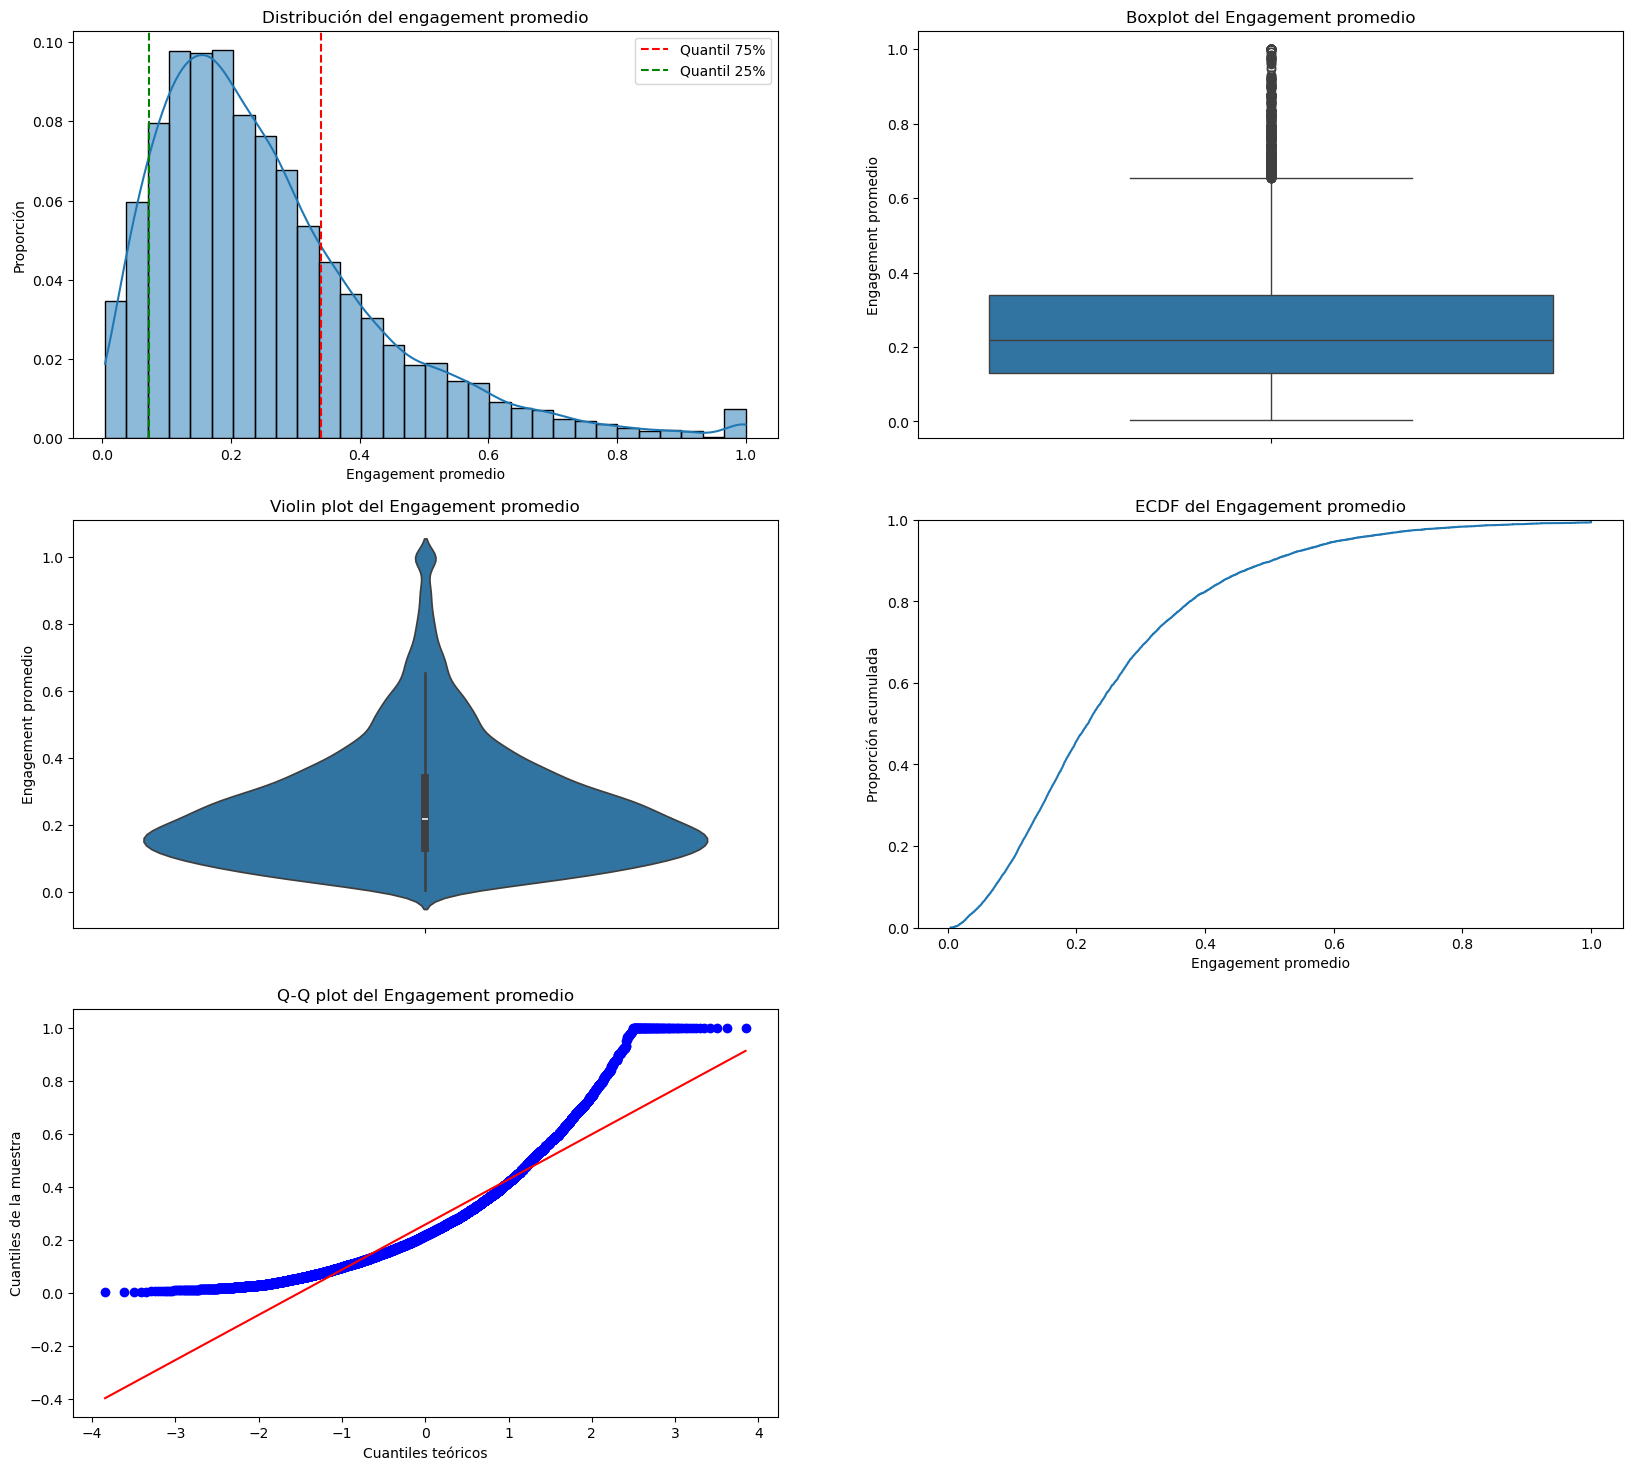

In [3]:
#Obtenemos las columnas relacionadas al engagement de los videos.
engagement = dataset[['min_engagement', 'max_engagement', 'mean_engagement']]

#Graficamos la distribución del engagement promedio utilizando diferentes tipos de gráficos para obtener una visión completa de su comportamiento.
plt.clf()
fig, axs = plt.subplots(3, 2, figsize=(20, 18))
sns.histplot(engagement['mean_engagement'], bins=30, kde= True, stat='probability', ax=axs[0,0])
axs[0,0].axvline(engagement['mean_engagement'].quantile(0.75), linestyle="--", label= 'Quantil 75%', color='red')
axs[0,0].legend()
axs[0,0].axvline(engagement['mean_engagement'].quantile(0.1), linestyle="--", label= 'Quantil 25%', color='green')
axs[0,0].legend()
axs[0,0].set_title('Distribución del engagement promedio')
axs[0,0].set_xlabel('Engagement promedio')
axs[0,0].set_ylabel('Proporción')

sns.boxplot(y=engagement['mean_engagement'], ax=axs[0,1])
axs[0,1].set_title('Boxplot del Engagement promedio')
axs[0,1].set_ylabel('Engagement promedio')

sns.violinplot(y=engagement['mean_engagement'], ax=axs[1,0])
axs[1,0].set_title('Violin plot del Engagement promedio')
axs[1,0].set_ylabel('Engagement promedio')

sns.ecdfplot(engagement['mean_engagement'], ax=axs[1,1])
axs[1,1].set_title('ECDF del Engagement promedio')
axs[1,1].set_xlabel('Engagement promedio')
axs[1,1].set_ylabel('Proporción acumulada')

stats.probplot(engagement['mean_engagement'], dist="norm", plot=axs[2,0])
axs[2,0].set_title('Q-Q plot del Engagement promedio')
axs[2,0].set_xlabel('Cuantiles teóricos')
axs[2,0].set_ylabel('Cuantiles de la muestra')

axs[2,1].axis('off')



El análisis exploratorio mediante visualizaciones (histogramas y curvas de densidad) evidencia una distribución desbalanceada del engagement. Inicialmente se evaluó la posibilidad de definir un umbral natural analizando la relación entre el engagement mínimo, máximo y promedio; sin embargo, no se observó una ruptura estructural clara que permitiera establecer una frontera robusta entre niveles de engagement.

Ante la ausencia de un punto de separación natural, se optó por una estrategia basada en **cuantiles**. En particular, se define como **High Engagement** a aquellos videos cuyo *engagement promedio* se encuentra en el **cuartil superior (percentil 75)** de la distribución.

C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\1889370055.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Engagement', data=dataset, ax=ax[1], palette=['lightcoral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\1889370055.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['No Engagement', 'Sí Engagement'])


<Figure size 640x480 with 0 Axes>

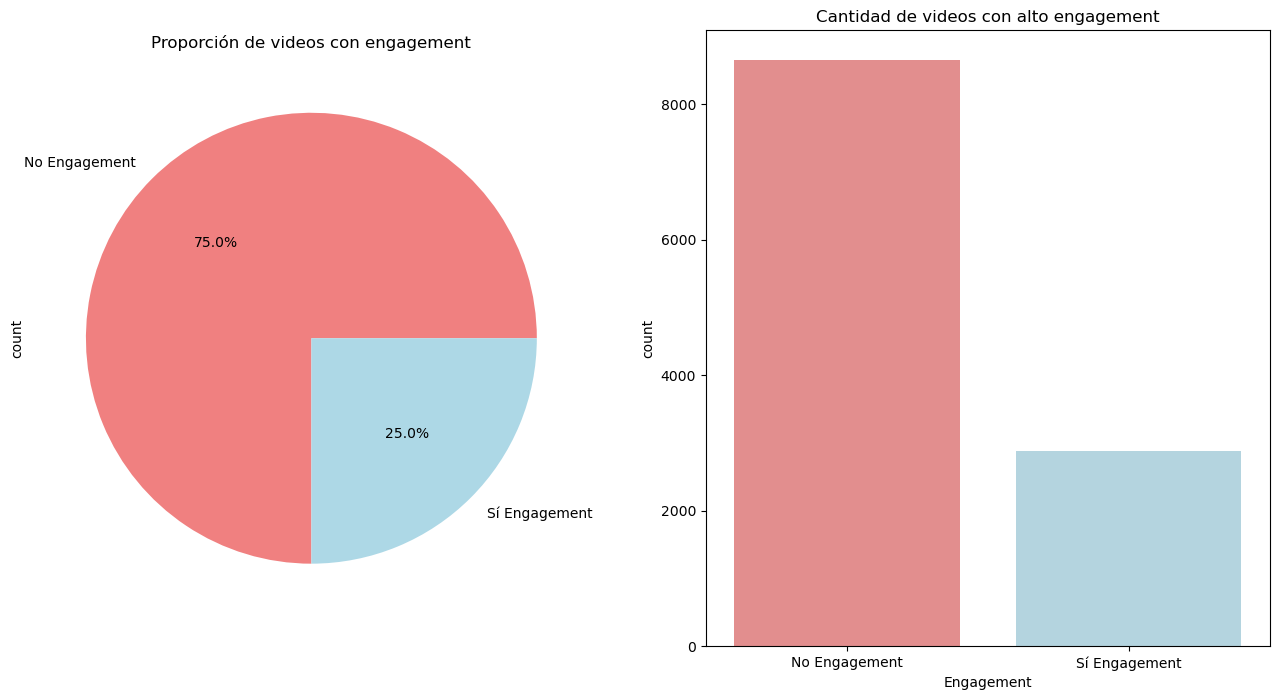

In [4]:
#Obtenemos el engagement promedio que completa el 75% del data set
threshold = dataset['mean_engagement'].quantile(0.75)

#Creamos la variable objetivo a partir del umbral 
dataset['Engagement'] = (dataset['mean_engagement'] >= threshold).astype(int)

#Grafico de pastel para analizar la proporción de videos con alto engagement e histograma para ver la cantidad de videos con alto engagement
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
labels = ['No Engagement', 'Sí Engagement']
dataset['Engagement'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0], colors=['lightcoral', 'lightblue'], labels = labels)
ax[0].set_title('Proporción de videos con engagement')
sns.countplot(x='Engagement', data=dataset, ax=ax[1], palette=['lightcoral', 'lightblue'])
ax[1].set_title('Cantidad de videos con alto engagement')
ax[1].set_xticklabels(['No Engagement', 'Sí Engagement'])
plt.show()


## Prevención de Data Leakage y eliminación de variables no disponibles en producción

## Prevención de Data Leakage

Una vez construida la variable objetivo (`high_engagement`), se realizó una revisión de las variables de entrada con el fin de evitar **data leakage** y asegurar que el modelo utilice únicamente información disponible **antes de la publicación del video**.

Dado que el objetivo es predecir el nivel de engagement de forma **ex-ante**, se eliminaron todas aquellas variables que contienen información derivada del comportamiento posterior de los usuarios o que no aportan valor predictivo directo.

Las variables retiradas corresponden a las siguientes categorías:

- **Identificadores y particiones:** 
  
- **Variables derivadas del engagement (leakage directo):**  
  
- **Identificadores de tópicos:**  
  en su lugar se conservaron sus respectivos **scores numéricos**.

- **Métricas dependientes del comportamiento de los usuarios:**  
  
- **Variable categórica sin contexto semántico claro:**  
  



In [ ]:
X = dataset.drop(columns=['id', 'Engagement', 'fold', 'min_engagement', 'med_engagement', 
                          'max_engagement', 'mean_engagement', 'sd_engagement',
                          'auth_topic_rank_1_url', 'auth_topic_rank_2_url', 'auth_topic_rank_3_url',
                            'auth_topic_rank_4_url', 'auth_topic_rank_5_url',
                            'coverage_topic_rank_1_url', 'coverage_topic_rank_2_url', 'coverage_topic_rank_3_url',
                            'coverage_topic_rank_4_url', 'coverage_topic_rank_5_url',
                            'type','num_learners', 'num_views', 'avg_star_rating', 'num_star_ratings'])
Y = dataset['Engagement']




## Tratamiento de valores faltantes (***Missing Values***)

Durante el análisis exploratorio se identificaron valores faltantes en las variables `categories`, `auth_topic_rank_2_score` – `auth_topic_rank_5_score` y `coverage_topic_rank_2_score` – `coverage_topic_rank_5_score`.

En el caso de las variables de tópicos (`auth_topic_` y `coverage_topic_`), los valores faltantes no representan errores de registro. Estos scores corresponden a los **Top-5 tópicos más relevantes** de cada video; cuando un video no presenta suficientes tópicos con relevancia significativa, los ranks inferiores simplemente no existen. Por esta razón, los valores faltantes se reemplazaron por **0**, interpretándolos como ausencia de contribución temática en ese nivel de ranking.

Para la variable categórica `categories` (≈9% de valores faltantes), no se eliminaron observaciones. Los valores faltantes se manejaron implícitamente durante el proceso de **One-Hot Encoding**, permitiendo que la ausencia de categoría quede representada en las variables resultantes.

### ***Categories***

C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\3059010579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=X, ax=axes[i], palette=['lightcoral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\3059010579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=X, ax=axes[i], palette=['lightcoral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\3059010579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=X, ax=axes[i], palette=['lightcoral', 'lightblue'])


<Figure size 640x480 with 0 Axes>

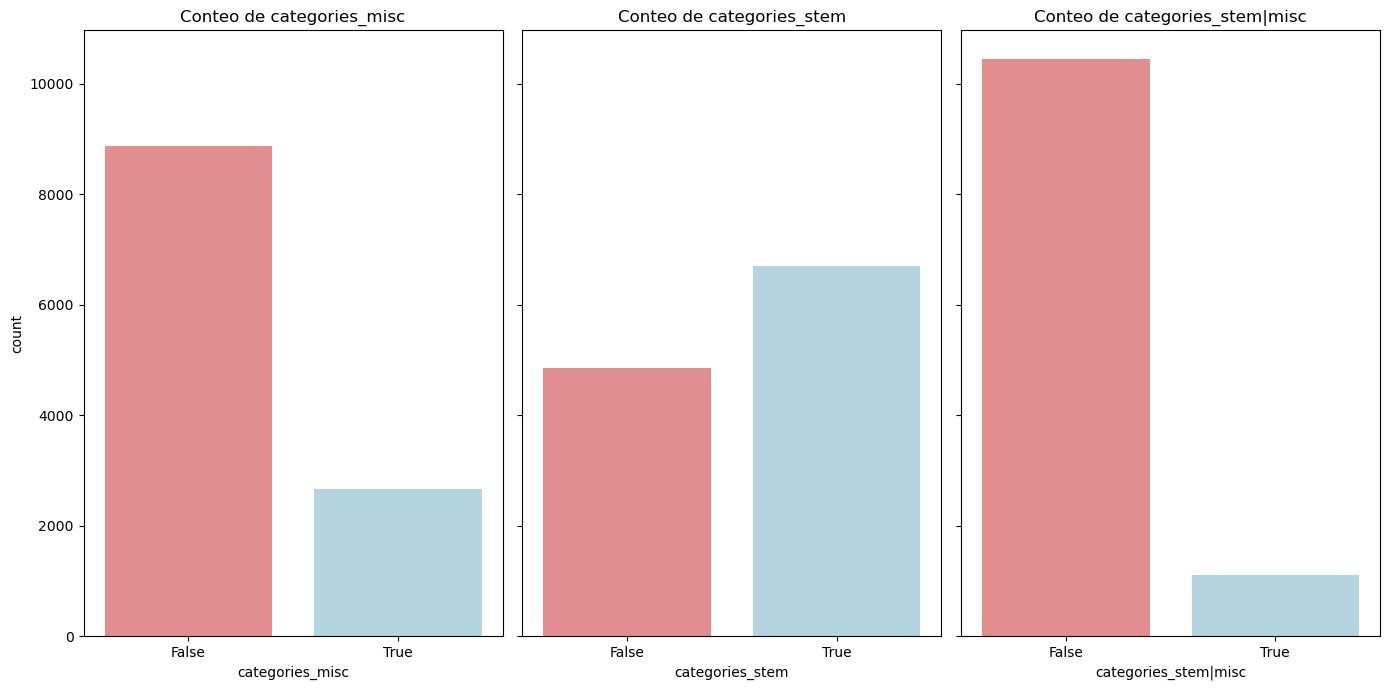

In [6]:
#Aplicamos fillna a la columna categories
X['categories'] = X['categories'].fillna('Unknown')

#aplicamos one-hot-encoding a la columna categories
X = pd.get_dummies(X, columns=['categories'], drop_first= True, prefix='categories')

#Pasamos los datos de True y False a 1 y 0 respectivamente
X[['categories_stem', 'categories_misc', 'categories_stem|misc' ]] = X[['categories_stem', 'categories_misc', 'categories_stem|misc' ]].astype(int)

plt.clf()
fig, axes = plt.subplots(1, 3, figsize= (14,7), sharey= True)
for i, col in enumerate(['categories_misc', 'categories_stem', 'categories_stem|misc']):
     sns.countplot(x=col, data=X, ax=axes[i], palette=['lightcoral', 'lightblue'])
     axes[i].set_title(f'Conteo de {col}')
     axes[i].set_xticks([0,1])
     axes[i].set_xticklabels(['False', 'True'])
plt.tight_layout()
plt.show()



### ***Authority, Coverage, has parts feautures***


In [7]:
rank_cols = X.filter(regex='auth_topic_rank|coverage_topic_rank').columns
X[rank_cols] = X[rank_cols].fillna(0)
X['has_parts'] = X['has_parts'].astype(int)

## EDA variables de entrada

El análisis exploratorio mostró que las variables presentan **distribuciones diversas**, incluyendo distribuciones aproximadamente normales y otras con **asimetría hacia la izquierda o derecha**. También se identificaron **valores extremos (outliers)** en algunas variables; sin embargo, estos parecen corresponder a observaciones válidas, por lo que se decidió conservarlos.



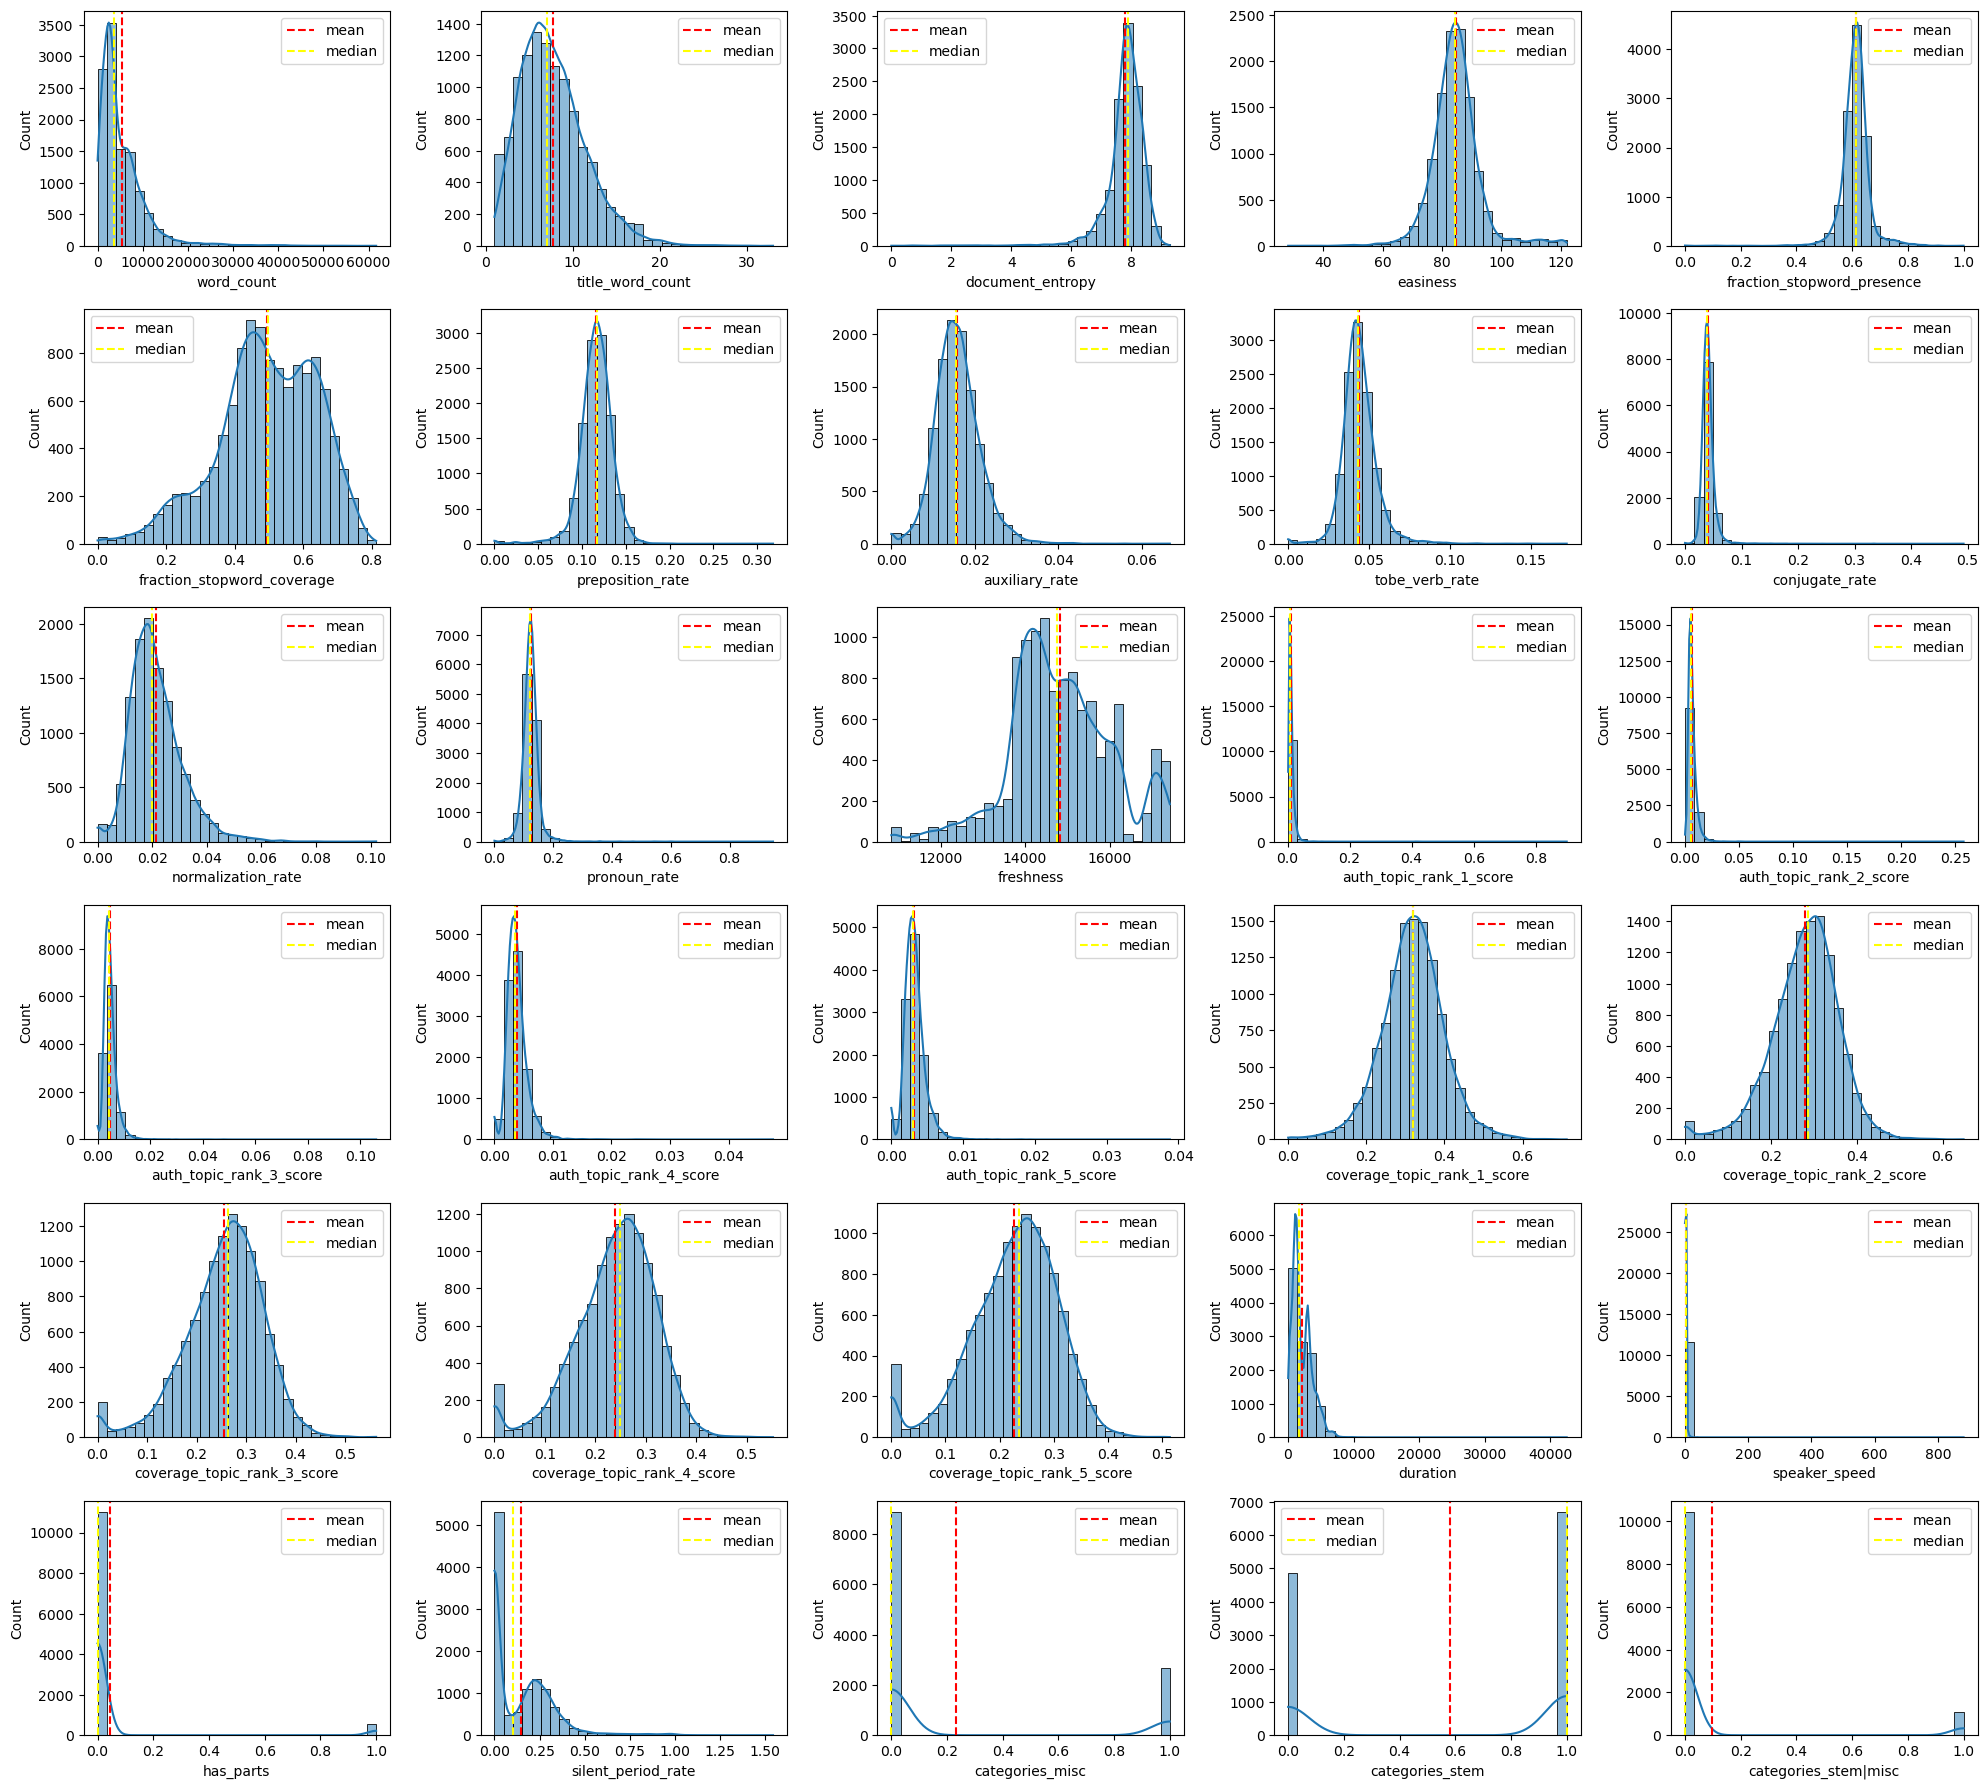

In [8]:
fig, axs = plt.subplots(6, 5, figsize=(20,18))
for i, feature in enumerate(X.columns):
    ax=axs[i//5, i%5]
    sns.histplot(data= X[feature], bins= 30, kde= True, ax = ax)
    ax.axvline(X[feature].mean(), linestyle= '--', color= 'red', label = 'mean')
    ax.axvline(X[feature].median(), linestyle= '--', color= 'yellow', label = 'median')
    ax.legend()
plt.tight_layout()


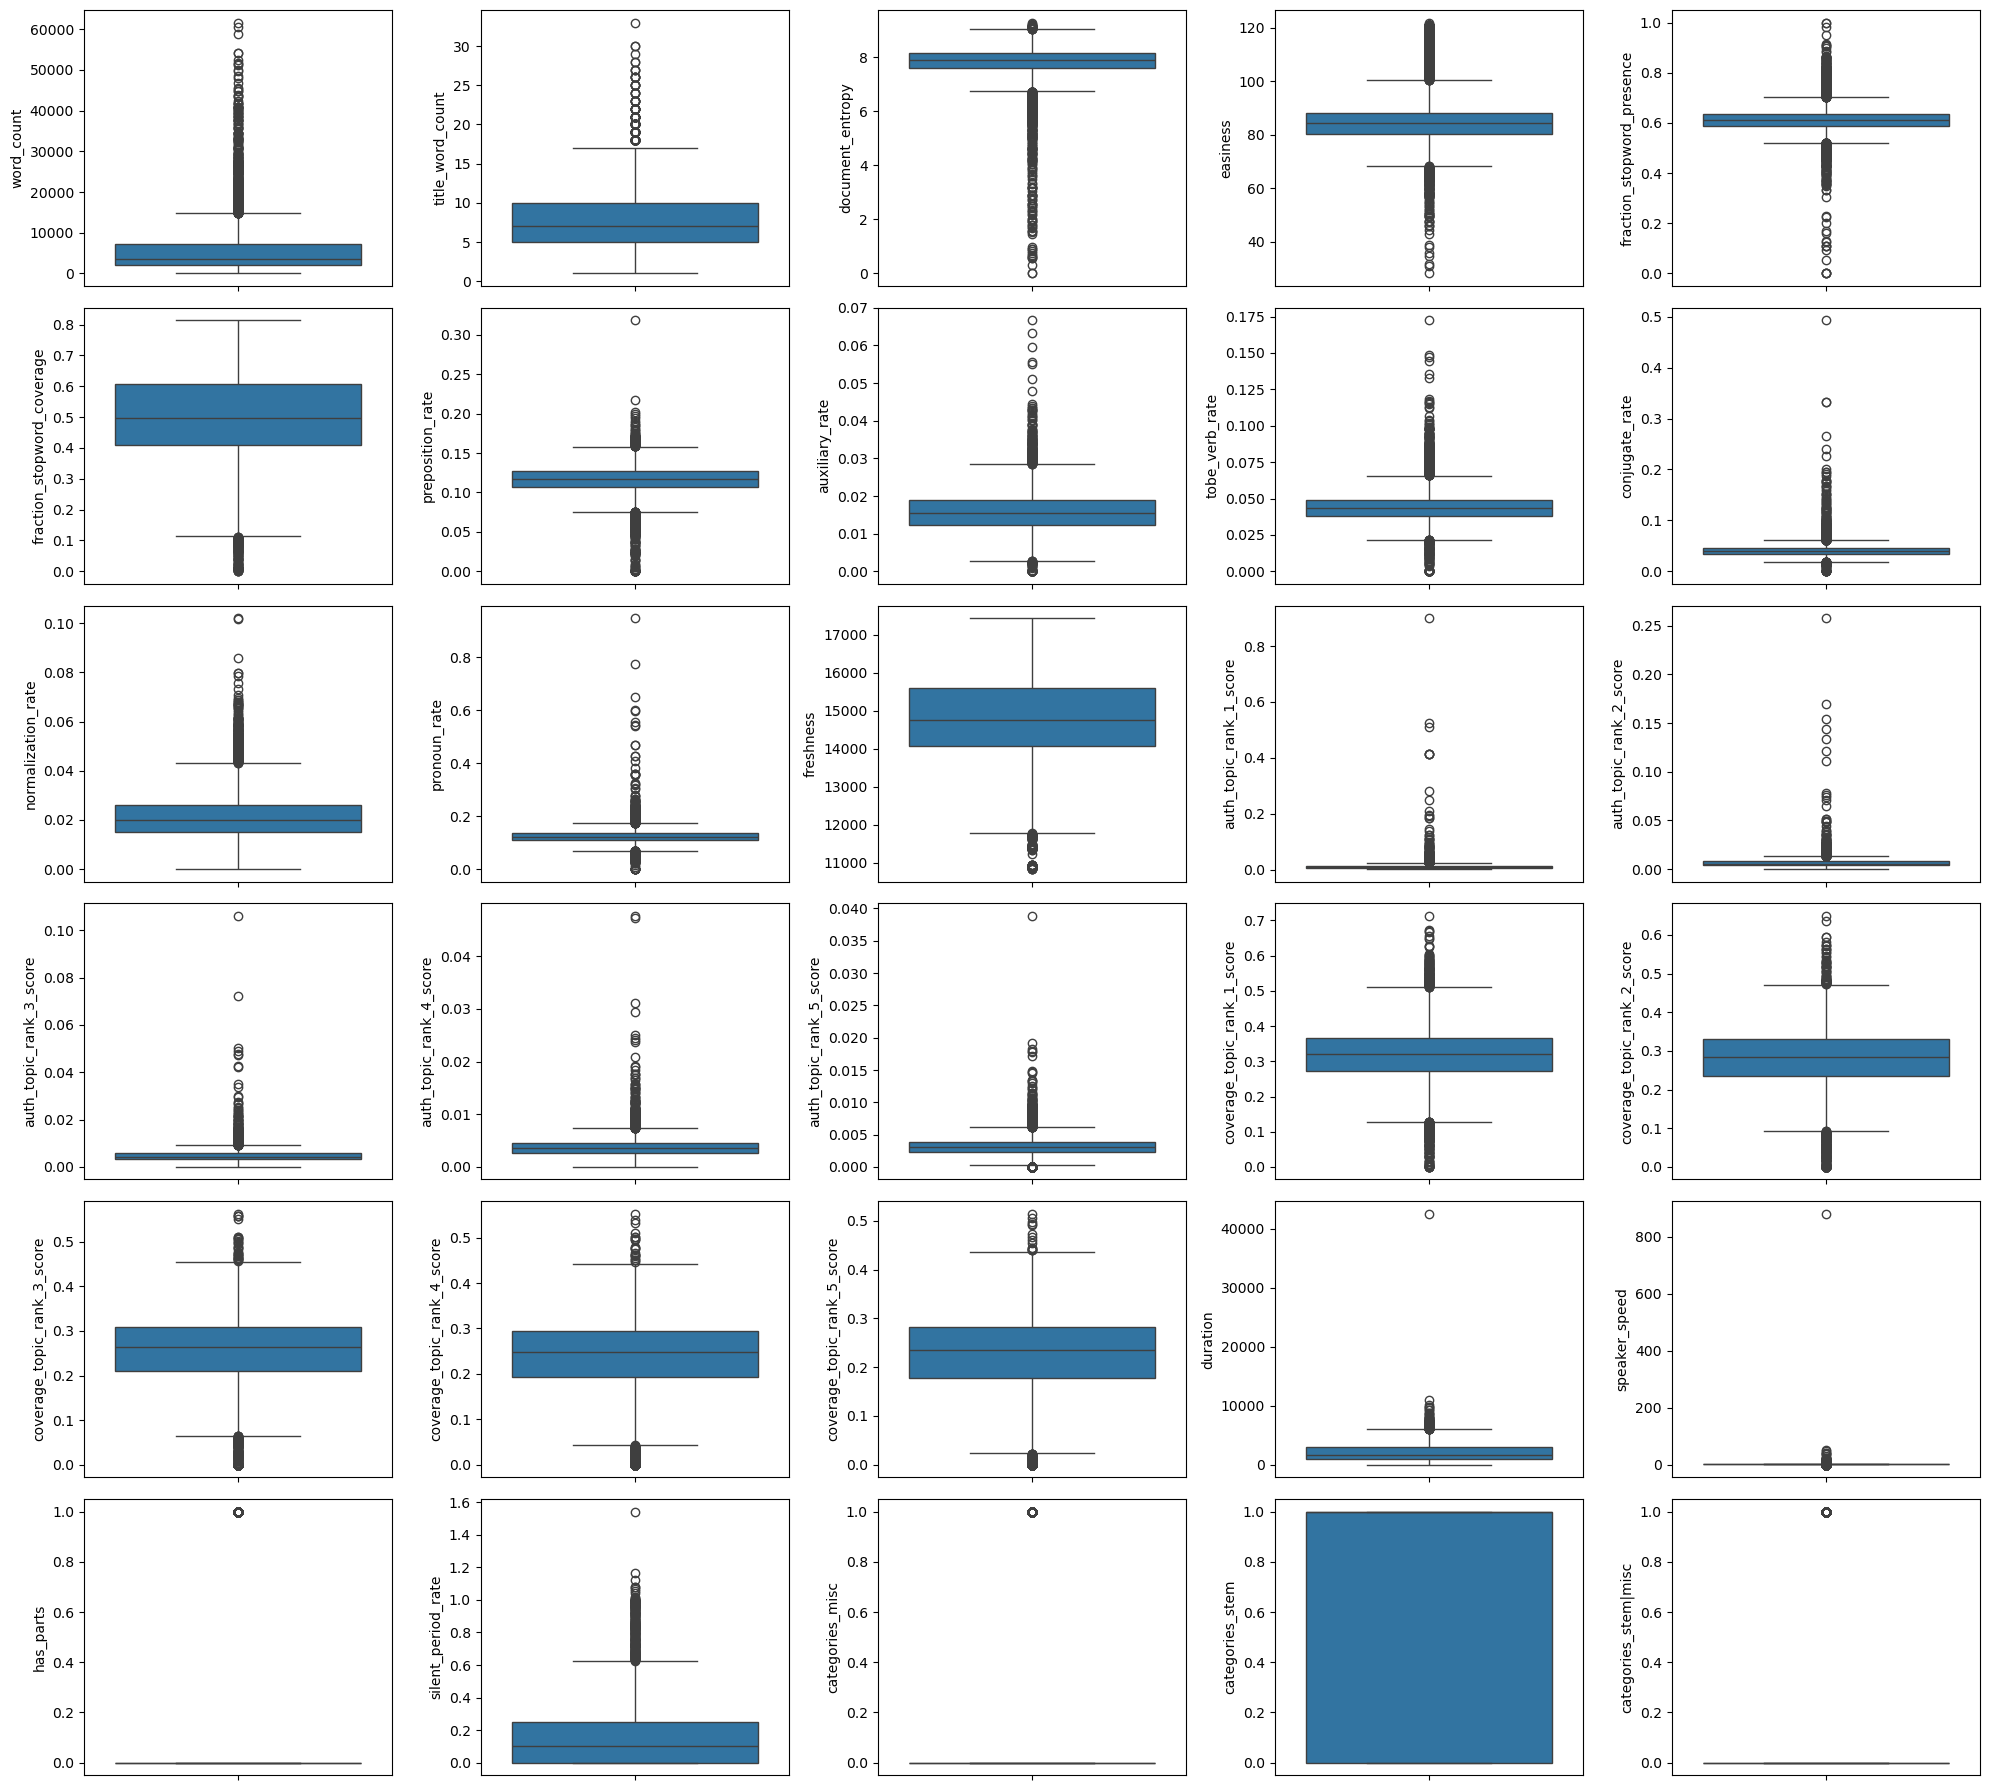

In [9]:
fig, axs = plt.subplots(6, 5, figsize=(20,18))
for i, feature in enumerate(X.columns):
    ax=axs[i//5, i%5]
    sns.boxplot(data= X[feature], ax = ax)
plt.tight_layout()

## Reducción de dimensionalidad y análisis estructural de las variables

Con el objetivo de reducir redundancias, mitigar la multicolinealidad y evaluar diferentes representaciones del espacio de características, se aplicaron dos estrategias complementarias de reducción de dimensionalidad:

- **Reducción estructural basada en correlación**
- **Reducción mediante Análisis de Componentes Principales (PCA)**

Esto permitió construir múltiples versiones del dataset para comparar su impacto en el rendimiento de los modelos.

### Análisis de correlación

Primero se evaluó la relación entre cada variable de entrada y la variable objetivo (`high_engagement`) utilizando **correlación punto-biserial**, reteniendo únicamente aquellas variables con:

- |correlación| ≥ 0.08  
- p-valor < 0.05

Posteriormente se analizó la **correlación entre variables de entrada** mediante **correlación de Spearman**, identificando posibles problemas de multicolinealidad. Cuando dos variables presentaban alta correlación (|ρ| > 0.80 y p < 0.05), se eliminaron aquellas con menor relevancia respecto al target o mayor redundancia estructural.

Este proceso dio lugar a un subconjunto de variables con menor redundancia y mejor señal estadística:

- `X_train_reduce`
- `X_test_reduce`

### Reducción basada en PCA

Como enfoque alternativo, se aplicó **Análisis de Componentes Principales (PCA)** para obtener una representación latente del espacio de variables. Previamente, las variables fueron **estandarizadas con StandardScaler**, dado que PCA es sensible a la escala.

Se seleccionó un número de componentes que retuviera aproximadamente **80% de la varianza total**, generando los conjuntos:

- `X_train_pca`
- `X_test_pca`

Las componentes resultantes capturan información relacionada con la **estructura del contenido, complejidad lingüística, relevancia temática, dinámica temporal y tipo de contenido**, permitiendo evaluar si una representación latente mejora el desempeño predictivo frente al conjunto de variables originales.

### ***PCA***

<Figure size 640x480 with 0 Axes>

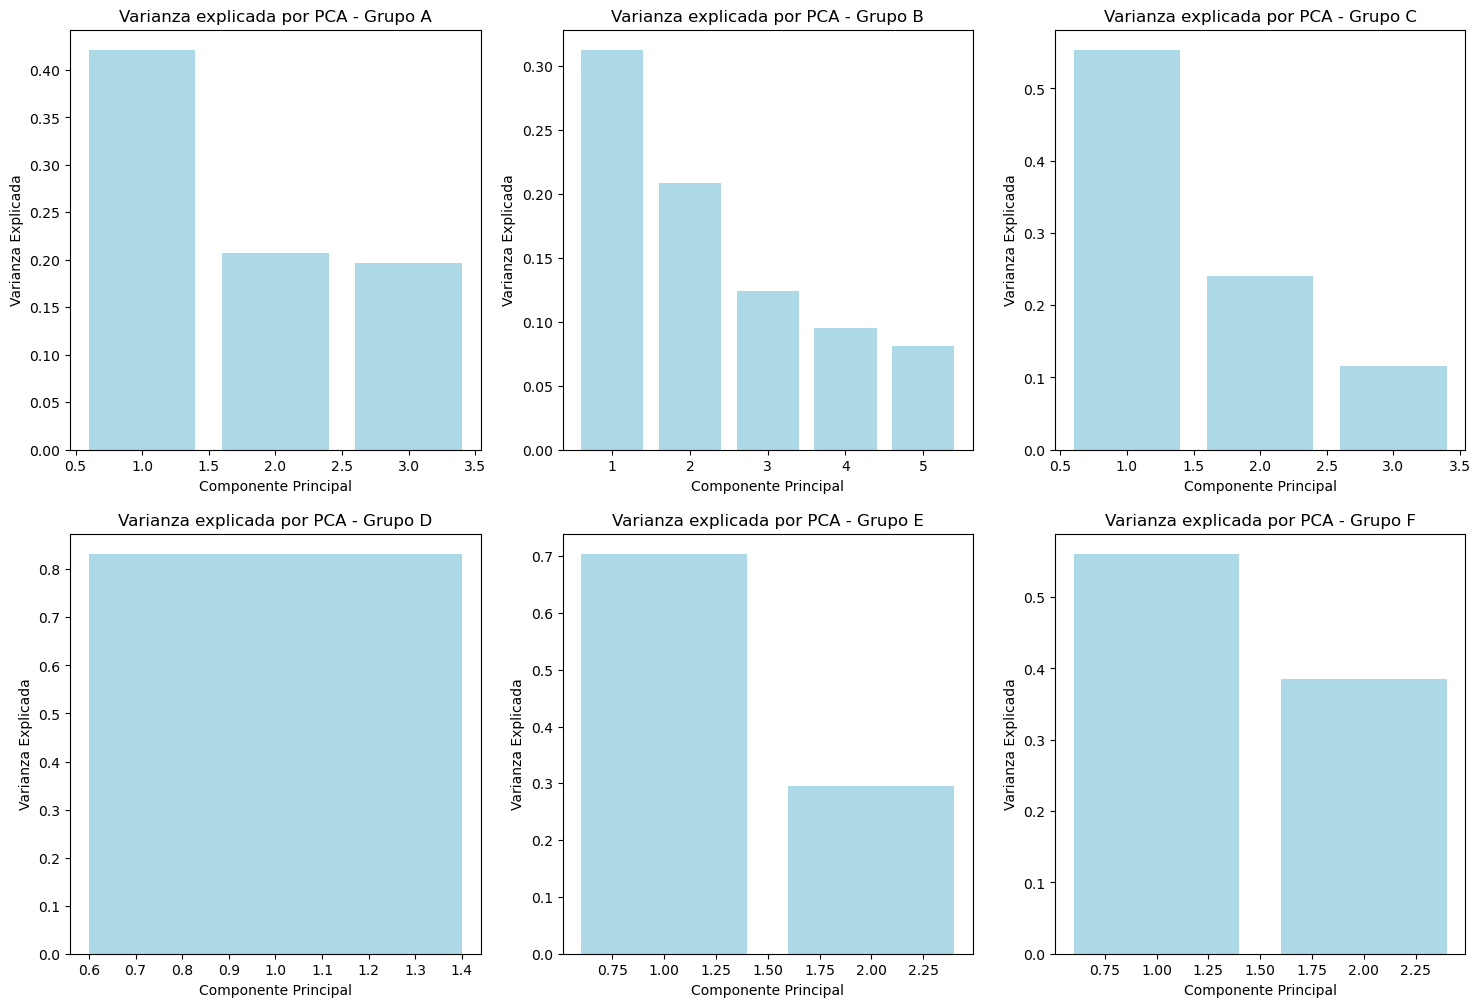

In [10]:
#Creamos el dataset para entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

#Creación de función para aplicar realizar PCA a cada agrupación de features
def PCA_train_test(feature_group_train, feature_group_test):
    #configuramos el escalador
    scaler = StandardScaler()
    #configuramos la función PCA
    PCA_ = PCA(n_components= 0.8)
    
    #PARA TRAIN DATA
    #Ajustamos y escalamos el grupo de caracteristicas
    train_features_scaled = scaler.fit_transform(feature_group_train)
    #Ajustamos y aplicamos PCA al grupo de caracteristicas 
    train_components = PCA_.fit_transform(train_features_scaled)

    #PARA TEST DATA
    #Aplicamos la escala ya ajustada por TRAIN
    test_features_scaled = scaler.transform(feature_group_test)
    #Aplicamos la función PCA ya ajustada por TRAIN
    test_components = PCA_.transform(test_features_scaled)
    
    return [train_components, test_components, PCA_]

#AGRUPACIONES

#A) Tamaño y estructura del contenido
group_A = ['word_count','title_word_count','duration','speaker_speed','has_parts']

#B) Complejidad lingüística:
group_B = ['document_entropy','easiness','fraction_stopword_presence','fraction_stopword_coverage'
,'preposition_rate','auxiliary_rate','tobe_verb_rate','conjugate_rate','normalization_rate','pronoun_rate']

#C) Estructura temática (muy potente):
group_C_auth = [f"auth_topic_rank_{i}_score" for i in range(1,6)]
group_C_cov = [f"coverage_topic_rank_{i}_score" for i in range(1,6)]

#D) Dinamica temporal
group_D = ['silent_period_rate', 'freshness']

#E) Tipo de contenido 
group_E = ['categories_misc','categories_stem','categories_stem|misc']

X_train_pca = pd.DataFrame()
X_test_pca = pd.DataFrame()
pca_results = {} # Diccionario para almacenar los resultados de PCA para cada grupo
pca_results_accumulative = {}
#Ciclo FOR para cada aplicar la función a cada grupo y extraer el resultado a los nuevos df
for group in [group_A, group_B, group_C_auth, group_C_cov, group_D, group_E]:
    train_components, test_components, PCA_ = PCA_train_test(X_train[group], X_test[group])
    pca_results[tuple(group)] = PCA_.explained_variance_ratio_ # Guardamos la varianza explicada para cada grupo
    pca_results_accumulative[tuple(group)] = PCA_.explained_variance_ratio_.cumsum()
    #Extraemos las componentes restantes a nuevos dataframes para concatenarlos 
    # luego a los df que almacenaran las componentes de cada grupo
    train_components_df = pd.DataFrame(train_components)
    test_components_df = pd.DataFrame(test_components)

    X_train_pca = pd.concat([X_train_pca, train_components_df], axis=1)
    X_test_pca = pd.concat([X_test_pca, test_components_df], axis=1)
#Graficamos la varianza que explica cada componente para cada grupo de caracteristicas
plt.clf()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, (group, var_exp) in enumerate(pca_results.items()):
    ax = axes[i//3, i%3]
    ax.bar(range(1, len(var_exp)+1), var_exp, color='lightblue')
    ax.set_title(f'Varianza explicada por PCA - Grupo {chr(65+i)}')
    ax.set_xlabel('Componente Principal')
    ax.set_ylabel('Varianza Explicada')
plt.show()

<Figure size 640x480 with 0 Axes>

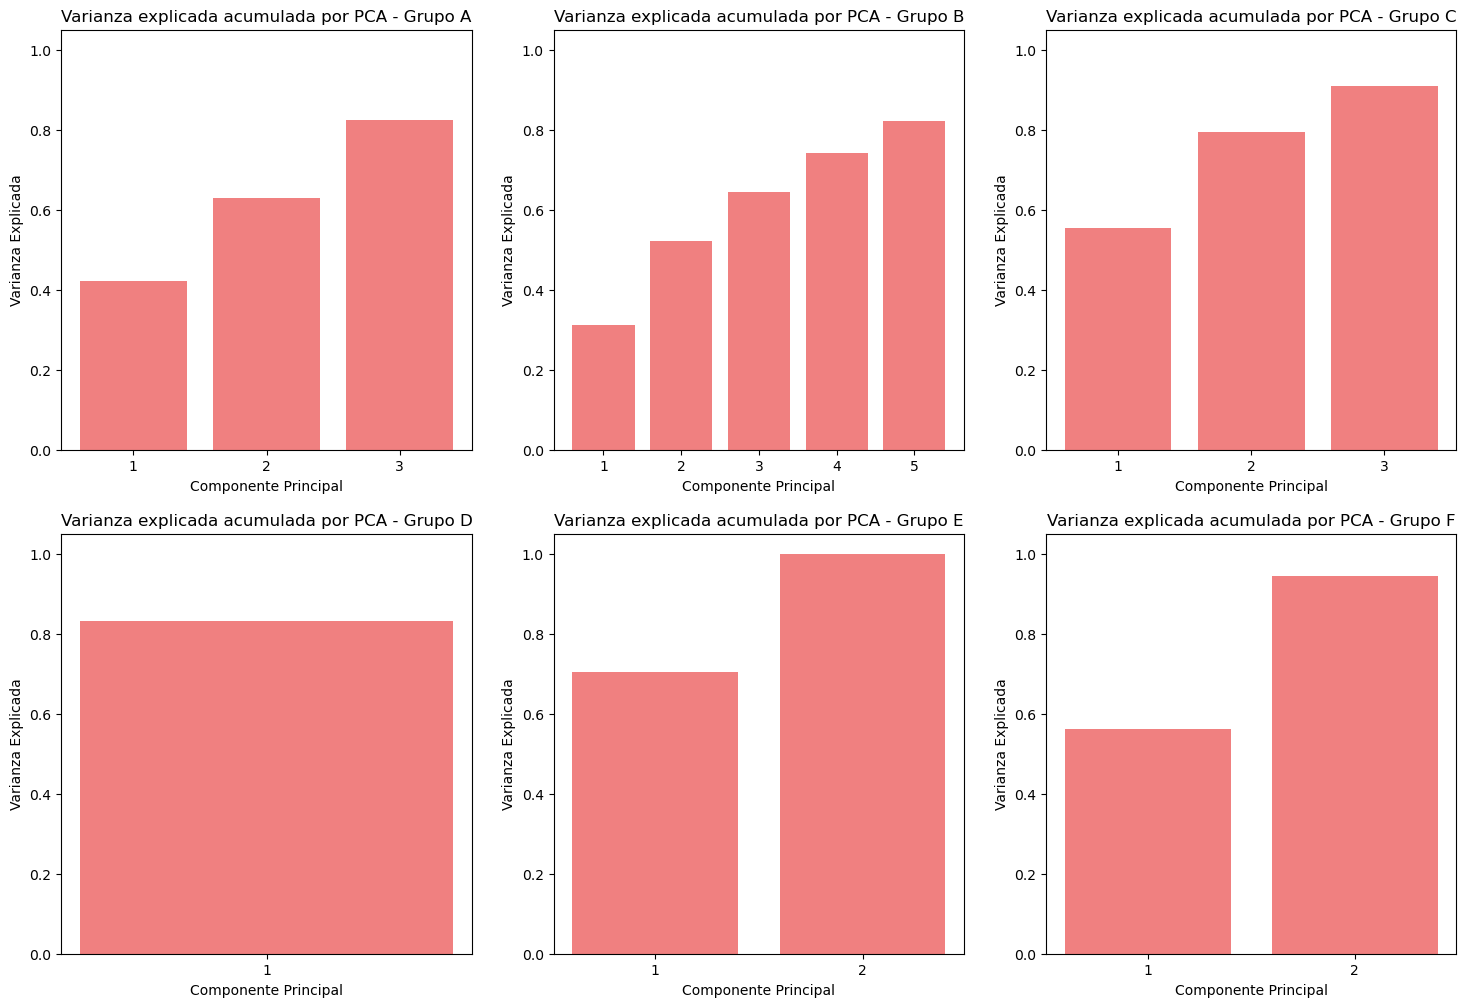

In [11]:
#Graficamos la varianza explicada acumulada para cada grupo de caracteristicas
plt.clf()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, (group, var_exp) in enumerate(pca_results_accumulative.items()):
    ax = axes[i//3, i%3]
    ax.bar(range(1, len(var_exp)+1), var_exp, color='lightcoral')
    ax.set_title(f'Varianza explicada acumulada por PCA - Grupo {chr(65+i)}')
    ax.set_xticks(range(1, len(var_exp)+1))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Componente Principal')
    ax.set_ylabel('Varianza Explicada')
plt.show()

### ***Analisis de correlación***

In [12]:
#Correlación con la variable objetivo (teniendo en cuenta que nuestra varieable objetivo es binaria, 
#usaremos la correlación de punto biserial)

results = dict()
for column in X_train.columns:
    coef, p_val = pointbiserialr(X_train[column], Y_train)
    results[column] = {'Correlation': coef, 'P_value': p_val}
results_df = pd.DataFrame(results).T.sort_values(by= 'Correlation', ascending= False)
results_df

,Correlation,P_value
freshness,0.264339,1.657369e-147
auth_topic_rank_5_score,0.249173,9.303069e-131
auth_topic_rank_4_score,0.229603,8.711191e-111
auth_topic_rank_3_score,0.225130,1.778299e-106
auth_topic_rank_2_score,0.156387,1.157776e-51
normalization_rate,0.082024,2.881048e-15
auth_topic_rank_1_score,0.081722,3.640526e-15
preposition_rate,0.067669,7.487286e-11
categories_stem|misc,0.048469,3.151910e-06
coverage_topic_rank_1_score,0.024182,2.011004e-02


Usando una confianza de ***95%*** y ***P-valor*** nos damos cuenta que no hay evidencia estadistica de que las siguientes variables presenten correlación significativa con la variable objetivo: 
- conjugate_rate
- coverage_topic_rank_(2, 3, 4, Y 5)_score
- title_word_count
- categories_(misc y stem)

A partir del analisis de el ***coeficiente de correlación*** encontramos que las siguientes variables no tiene la suficiente correlación para ser consideradas:

- preposition_rate
- categories stem|misc
- coverage_topic_rank_1_score
- word_per_second
- auxiliarity_rate
- tobe_verb_rate
- has parts


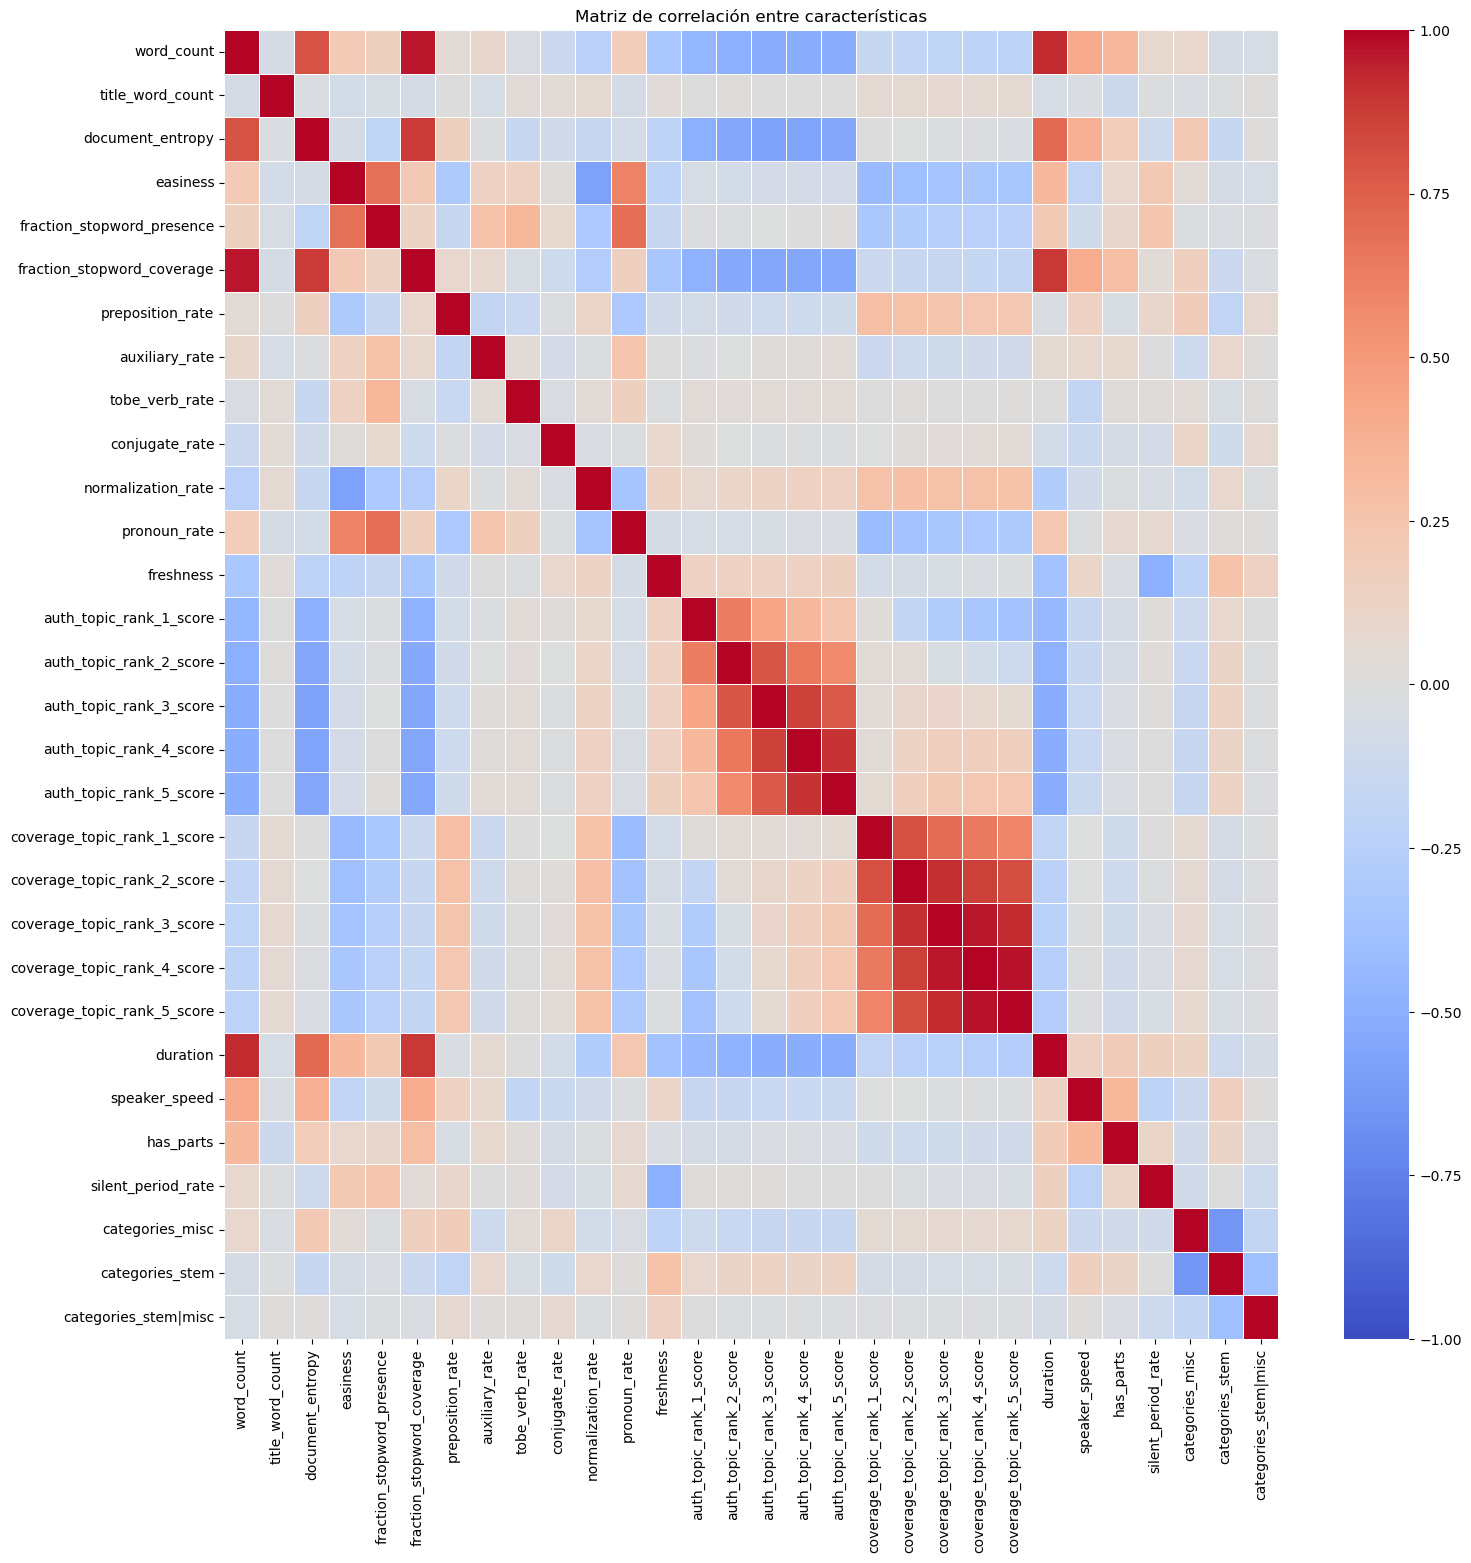

In [13]:
corr_matrix = X_train.corr(method= 'spearman')
corr_matrix
plt.figure(figsize=(17,17))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5, vmin= -1, vmax= 1)
plt.title('Matriz de correlación entre características')
plt.show()

tras el analisis de la matriz de correlación y el mapa de calor dado mediente esta, se sospecha que las siguientes variables estan altamente correlacionadas:

- word_count y duration
- word_count y fraction_stopword_coverage
- word_count y document entropy
- document_entropy y fraction_stopword_coverage
- duration y fraction_stopword_coverage
- coverage_topic_rank_(1 y 2, 2 y 3, 3 y 4, 4 y 5)_score
- auth_topic_rank(3 y 4, 4 y 5)

Ahora estudiemos como tal el valor del coeficiente para cada caso y su P_valor


In [14]:
X_train_copy = X_train.copy()

# Crear matrices vacías
corr_matrix = pd.DataFrame(np.zeros((X_train_copy.shape[1], X_train_copy.shape[1])), 
                           columns=X_train_copy.columns, 
                           index=X_train_copy.columns)

pval_matrix = pd.DataFrame(np.zeros((X_train_copy.shape[1], X_train_copy.shape[1])), 
                           columns=X_train_copy.columns, 
                           index=X_train_copy.columns)

# Calcular correlación y p-value para cada par
for i in range(len(X_train_copy.columns)):
    for j in range(len(X_train_copy.columns)):
        coef, p = spearmanr(X_train_copy.iloc[:, i], X_train_copy.iloc[:, j])
        corr_matrix.iloc[i, j] = coef
        pval_matrix.iloc[i, j] = p

In [15]:
#Creamos una función para imprimir la correlación entre dos variables de entrada y su P-valor.
def print_correlation_and_pvalue(feature1, feature2):
    return print(f'correlation {feature1} and {feature2}:\ncoef:{corr_matrix[feature1].loc[feature2]}, p-value: {pval_matrix[feature1].loc[feature2]}\n')

#Revisamos la correlación entre las variables analizadas en el mapa de calor
print_correlation_and_pvalue('word_count', 'duration')
print_correlation_and_pvalue('word_count', 'fraction_stopword_coverage')
print_correlation_and_pvalue('word_count', 'document_entropy')
print_correlation_and_pvalue('document_entropy', 'fraction_stopword_coverage')

authority_score = [f'auth_topic_rank_{i}_score' for i in range(3, 6)]
coverage_score = [f'coverage_topic_rank_{i}_score' for i in range(1, 6)]

for i in range(len(authority_score)-1): 
    print_correlation_and_pvalue(authority_score[i], authority_score[i+1])

for i in range(len(coverage_score)-1): 
    print_correlation_and_pvalue(coverage_score[i], coverage_score[i+1])

correlation word_count and duration:
coef:0.9251506187123995, p-value: 0.0

correlation word_count and fraction_stopword_coverage:
coef:0.9630564195824836, p-value: 0.0

correlation word_count and document_entropy:
coef:0.8036487343337472, p-value: 0.0

correlation document_entropy and fraction_stopword_coverage:
coef:0.8781471452294728, p-value: 0.0

correlation auth_topic_rank_3_score and auth_topic_rank_4_score:
coef:0.8641243118443562, p-value: 0.0

correlation auth_topic_rank_4_score and auth_topic_rank_5_score:
coef:0.8999526222758067, p-value: 0.0

correlation coverage_topic_rank_1_score and coverage_topic_rank_2_score:
coef:0.8083012367616619, p-value: 0.0

correlation coverage_topic_rank_2_score and coverage_topic_rank_3_score:
coef:0.9134127174766573, p-value: 0.0

correlation coverage_topic_rank_3_score and coverage_topic_rank_4_score:
coef:0.9613382594296819, p-value: 0.0

correlation coverage_topic_rank_4_score and coverage_topic_rank_5_score:
coef:0.9728025040568322, p-va

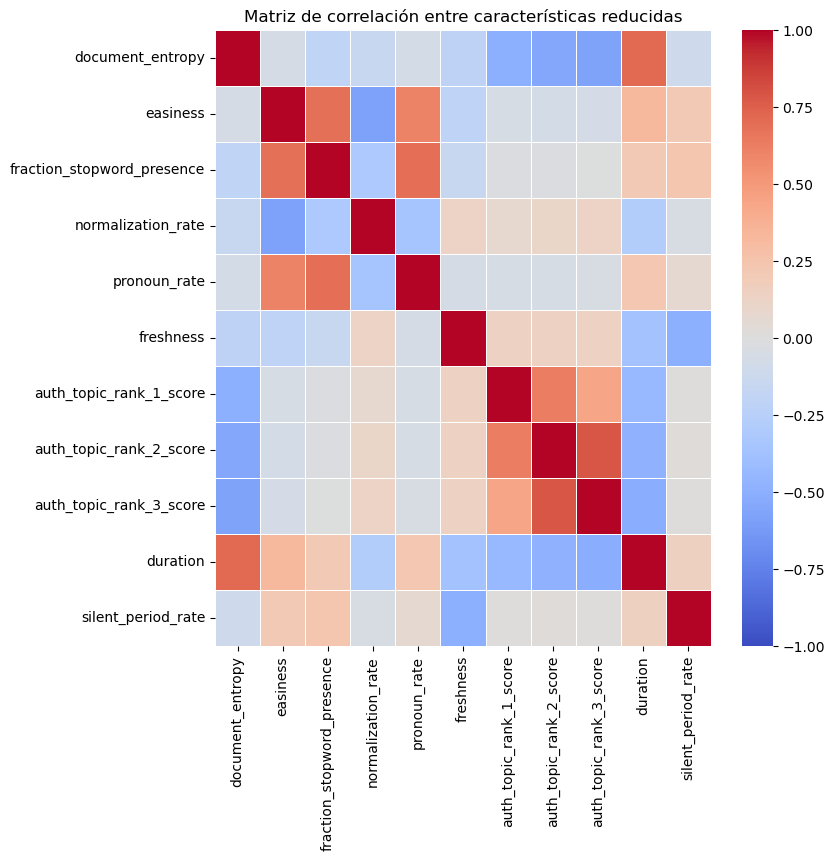

In [16]:
#Creamos los Dataframe donde solo se incluiran las variables aceptadas mediante el analisis
X_train_reduce = X_train.copy()
X_test_reduce = X_test.copy()

X_train_reduce = X_train_reduce.drop(columns = ['word_count', 'fraction_stopword_coverage','conjugate_rate',
'coverage_topic_rank_2_score', 'title_word_count', 'coverage_topic_rank_5_score', 'categories_misc',
'coverage_topic_rank_4_score', 'coverage_topic_rank_3_score', 'categories_stem', 'auth_topic_rank_4_score', 
'auth_topic_rank_5_score', 'preposition_rate', 'categories_stem|misc', 'coverage_topic_rank_1_score','speaker_speed'
,'auxiliary_rate','tobe_verb_rate' ,'has_parts'])

X_test_reduce = X_test_reduce.drop(columns = ['word_count', 'fraction_stopword_coverage','conjugate_rate',
'coverage_topic_rank_2_score', 'title_word_count', 'coverage_topic_rank_5_score', 'categories_misc',
'coverage_topic_rank_4_score', 'coverage_topic_rank_3_score', 'categories_stem', 'auth_topic_rank_4_score', 
'auth_topic_rank_5_score', 'preposition_rate', 'categories_stem|misc', 'coverage_topic_rank_1_score','speaker_speed'
,'auxiliary_rate','tobe_verb_rate' ,'has_parts'])

#Graficamos la correlación entre las variables restantes para revisar si hay alguna correlación fuerte entre ellas
plt.figure(figsize=(8,8))
sns.heatmap(X_train_reduce.corr(method= 'spearman'), cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5, vmin= -1, vmax= 1)
plt.title('Matriz de correlación entre características reducidas')
plt.show()

## Conjuntos de datos finales para modelado

Tras el proceso de preprocesamiento y reducción de dimensionalidad se generaron tres representaciones del dataset que serán utilizadas en la etapa de modelado:

1. **Dataset completo (Baseline)**  
   Incluye todas las variables preprocesadas, excluyendo aquellas eliminadas por *data leakage*.  
   - `X_train`  
   - `X_test`  
   Este conjunto sirve como **línea base** para evaluar el desempeño de los modelos sin aplicar reducción de dimensionalidad.

2. **Dataset reducido por análisis estructural**  
   Subconjunto de variables seleccionado mediante criterios de correlación con la variable objetivo y control de multicolinealidad.  
   - `X_train_reduce`  
   - `X_test_reduce`  
   Conserva únicamente variables con **señal estadística relevante y baja redundancia**.

3. **Dataset transformado mediante PCA**  
   Representación basada en **componentes principales** que explican aproximadamente el **80% de la varianza acumulada**.  
   - `X_train_pca`  
   - `X_test_pca`  
   Permite trabajar en un espacio de variables **no correlacionadas y de menor dimensionalidad**.

C:\Users\osqui\AppData\Local\Temp\ipykernel_20140\1507977933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset_labels, y=feature_counts, palette=['lightcoral', 'lightblue', 'lightgreen'], ax=ax)


<Figure size 640x480 with 0 Axes>

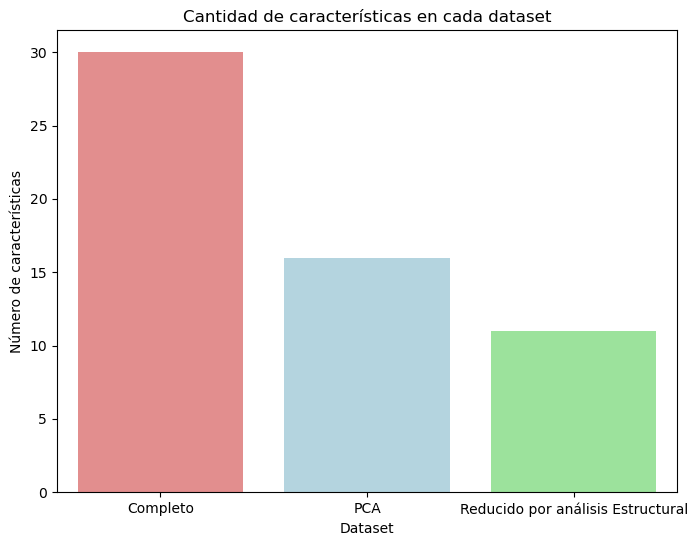

In [17]:
#Graficamos la cantidad de características en cada dataset para visualizar la reducción de dimensionalidad
plt.clf()
fig, ax = plt.subplots(figsize=(8, 6))
dataset_labels = ['Completo', 'PCA', 'Reducido por análisis Estructural']
feature_counts = [X_train.shape[1], X_train_pca.shape[1], X_train_reduce.shape[1]]
sns.barplot(x=dataset_labels, y=feature_counts, palette=['lightcoral', 'lightblue', 'lightgreen'], ax=ax)
ax.set_title('Cantidad de características en cada dataset')
ax.set_xlabel('Dataset')
ax.set_ylabel('Número de características')
plt.show()


In [18]:
import os

# Guardar datasets
X_train.to_pickle("../data/processed/X_train.pkl")
X_test.to_pickle("../data/processed/X_test.pkl")

X_train_reduce.to_pickle("../data/processed/X_train_reduce.pkl")
X_test_reduce.to_pickle("../data/processed/X_test_reduce.pkl")

X_train_pca.to_pickle("../data/processed/X_train_pca.pkl")
X_test_pca.to_pickle("../data/processed/X_test_pca.pkl")

Y_train.to_pickle("../data/processed/y_train.pkl")
Y_test.to_pickle("../data/processed/y_test.pkl")